# Modèle ENERGY

### Import des modules

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import missingno as msno # librairie pour identifier les données manquantes
import statsmodels.api as sm

In [19]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

In [20]:
pd.set_option('display.max_columns', None)  # Affiche toutes les colonnes

pd.set_option('display.max_rows', None) # Affiche toutes les lignes

### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [21]:
X = pd.read_csv("data/features.csv")
X = X.drop(columns=['SiteEnergyUse(kBtu)', 'LargestPropertyUseType'])

y = pd.read_csv("data/energy_target.csv").squeeze()

# Transformation logarithmique sur la target
y = np.log(y)

# Régression linéaire

In [22]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

scores = cross_validate(
    pipeline,
    X,
    y,
    cv=5,
    scoring={
        "r2": "r2",
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error"
    }
)

print("R² moyen :", scores["test_r2"].mean())
print("RMSE moyen :", -scores["test_rmse"].mean())
print("MAE moyen :", -scores["test_mae"].mean())

R² moyen : 0.2768443892800385
RMSE moyen : 0.5954318109846893
MAE moyen : 0.45196017830551616


# Random Forest

In [23]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

scores = cross_validate(
    rf,
    X,
    y,
    cv=5,
    scoring={
        "r2": "r2",
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error"
    },
    n_jobs=-1
)

r2_mean = scores["test_r2"].mean()
rmse_mean = -scores["test_rmse"].mean()
mae_mean = -scores["test_mae"].mean()

print("R² RF moyen :", r2_mean)
print("RMSE RF moyen :", rmse_mean)
print("MAE RF moyen :", mae_mean)
print("RMSE relatif RF :", rmse_mean / y.mean())

R² RF moyen : 0.27910564489571865
RMSE RF moyen : 0.5953680526375482
MAE RF moyen : 0.44192024485378684
RMSE relatif RF : 0.04246300583226947


# XGBoost

In [24]:
import xgboost as xgb
from sklearn.metrics import make_scorer, mean_absolute_error

model = xgb.XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
    random_state=42
)

scoring = {
    "r2": "r2",
    "mae": make_scorer(mean_absolute_error)
}

cv_results = cross_validate(
    model,
    X,
    y,
    cv=5,
    scoring=scoring,
    return_train_score=True
)

print("R2 moyen :", cv_results["test_r2"].mean())
print("MAE moyen :", cv_results["test_mae"].mean())

R2 moyen : 0.24699722515553518
MAE moyen : 0.45752902324287137


### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn. 

In [ ]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# grille d’hyperparamètres
param_grid = {
    "n_estimators": [300, 500, 800], # nombre d’arbres
    "max_depth": [None, 10, 20, 30], # profondeur maximale de chaque arbre
    "min_samples_split": [2, 5, 10], # nombre minimum d’observations nécessaires pour diviser un nœud
    "min_samples_leaf": [1, 2, 4], # nombre minimum d’observations dans une feuille finale
    "max_features": ["sqrt", "log2", 0.5], # contrôle le nombre de variables testées à chaque split
    "bootstrap": [True] # contrôle l’échantillonnage des données.
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5, # validation croisée en 5 sous-ensembles, 108 combinaisons × 5 = 540 entraînements
    scoring="r2",
    n_jobs=-1
)

grid.fit(X, y)

print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur R² CV :", grid.best_score_)

Meilleurs paramètres : {'bootstrap': True, 'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Meilleur R² CV : 0.3167044433274908


In [26]:
gain_r2 = grid.best_score_ - r2_mean
print("Gain sur le R² après optimisation des hyperparamètres : +" + str(gain_r2))

Gain sur le R² après optimisation des hyperparamètres : +0.03759879843177216


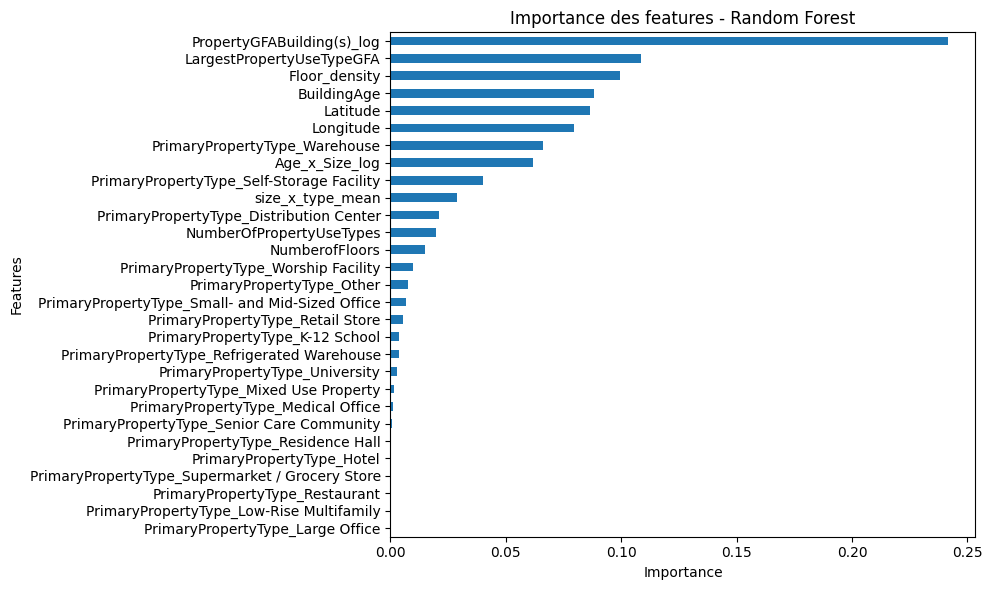

In [27]:
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importance.plot(kind="barh")
plt.title("Importance des features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()

plt.show()